In [23]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/raw/SuperStoreSales.csv")

In [24]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,8/11/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,8/11/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,12/6/2016,16/6/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,11/10/2015,18/10/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,11/10/2015,18/10/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [25]:
print("Shape:" , df.shape)
df.info()
df.describe()
df.isnull().sum()

Shape: (9994, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   flo

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [26]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ','_').str.replace('-','_')
df.columns

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub_category',
       'product_name', 'sales', 'quantity', 'discount', 'profit'],
      dtype='object')

In [27]:
df['order_date'] = pd.to_datetime(df['order_date'],dayfirst=True)
df['ship_date'] = pd.to_datetime(df['ship_date'],dayfirst=True)

In [28]:
df = df.dropna()


In [29]:
df.duplicated().sum()
df = df.drop_duplicates()

In [30]:
for col in df.columns:
    print(f"{col}")
    print(df[col].unique())

row_id
[   1    2    3 ... 9992 9993 9994]
order_id
['CA-2016-152156' 'CA-2016-138688' 'US-2015-108966' ... 'CA-2014-110422'
 'CA-2017-121258' 'CA-2017-119914']
order_date
<DatetimeArray>
['2016-11-08 00:00:00', '2016-06-12 00:00:00', '2015-10-11 00:00:00',
 '2014-06-09 00:00:00', '2017-04-15 00:00:00', '2016-12-05 00:00:00',
 '2015-11-22 00:00:00', '2014-11-11 00:00:00', '2014-05-13 00:00:00',
 '2014-08-27 00:00:00',
 ...
 '2016-10-11 00:00:00', '2014-06-18 00:00:00', '2017-02-28 00:00:00',
 '2015-05-09 00:00:00', '2014-11-06 00:00:00', '2015-12-29 00:00:00',
 '2014-04-03 00:00:00', '2016-06-03 00:00:00', '2015-04-12 00:00:00',
 '2014-01-21 00:00:00']
Length: 1237, dtype: datetime64[ns]
ship_date
<DatetimeArray>
['2016-11-11 00:00:00', '2016-06-16 00:00:00', '2015-10-18 00:00:00',
 '2014-06-14 00:00:00', '2017-04-20 00:00:00', '2016-12-10 00:00:00',
 '2015-11-26 00:00:00', '2014-11-18 00:00:00', '2014-05-15 00:00:00',
 '2014-09-01 00:00:00',
 ...
 '2017-04-06 00:00:00', '2015-05-13 00

In [31]:
df[['sales','profit','discount','quantity']].describe()

,sales,profit,discount,quantity
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,28.656896,0.156203,3.789574
std,623.245101,234.260108,0.206452,2.225110
min,0.444000,-6599.978000,0.000000,1.000000
25%,17.280000,1.728750,0.000000,2.000000
50%,54.490000,8.666500,0.200000,3.000000
75%,209.940000,29.364000,0.200000,5.000000
max,22638.480000,8399.976000,0.800000,14.000000


In [32]:
df[df['sales'] <0]

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,postal_code,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit


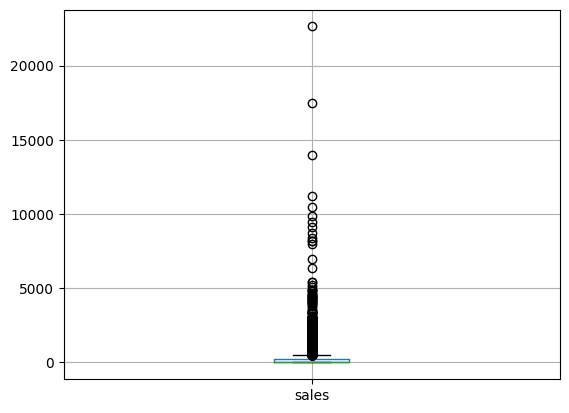

In [34]:
import matplotlib.pyplot as plt

df.boxplot(column ='sales')
plt.show()

In [35]:
df.to_csv("../data/processed/clean_superstore.csv",index=False)

In [36]:
## Summary

##The data set was validated and found to be largely clean.
##  Key actions include:
## - formatting starndardisation
## -date conversion
## - validation of categorical and numeric fields

## the cleaned dataset is not ready for exploration analysis and dashboard development.